<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/263150_Hernandez_Laboratorio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1 · Del dato histórico a una decisión de pronóstico

**Métodos para Pronóstico y Analítica Avanzada · MIAAD · UACJ**  
**Caso didáctico:** deserción escolar agregada como serie temporal semestral  
**Duración estimada:** 90 minutos  
**Modalidad:** trabajo individual guiado en Google Colab

---

Este laboratorio utiliza **datos simulados exclusivamente con fines didácticos**. No representan cifras reales de la UACJ ni deben interpretarse como resultados institucionales.


## Cómo trabajar en este cuaderno

1. Lea la explicación que aparece antes de cada bloque.
2. Ejecute la celda de código con el botón ▶ o con **Shift + Enter**.
3. Revise la tabla o gráfica obtenida.
4. Lea el apartado **Cómo interpretar el resultado**.
5. Para contestar, haga doble clic en la celda marcada como **Respuesta del estudiante**, escriba debajo de la línea indicada y presione **Shift + Enter** para volver a visualizarla.

No necesita escribir ni modificar código. En esta actividad, Python funciona como una calculadora reproducible; el aprendizaje central consiste en **formular, observar, comparar e interpretar**.

### Resultados de aprendizaje

Al terminar podrá:

- Formular una decisión que depende de un valor futuro.
- Identificar variable, frecuencia, origen y horizonte.
- Reconocer nivel, tendencia, estacionalidad y ruido.
- Construir baselines naïve y estacional.
- Calcular e interpretar MAE, RMSE y MAPE.
- Evaluar respetando el orden temporal.
- Traducir el error estadístico a una recomendación de decisión.


## Situación de decisión

La coordinación académica prepara el programa de tutorías, becas y acompañamiento para el siguiente semestre. Para reservar espacios y personal necesita anticipar **cuántos estudiantes podrían desertar**.

La decisión debe tomarse antes de conocer el número real. Si se subestima la deserción, podrían faltar recursos; si se sobreestima, podría reservarse capacidad que finalmente no se utilice.

> **Pregunta rectora:** ¿qué necesitamos estimar del futuro para decidir mejor hoy?


### Respuesta del estudiante

En dos o tres oraciones, explique quién utilizará el pronóstico, qué decisión tomará y por qué no puede esperar a conocer el dato real.

> **Escriba aquí su respuesta:**  
> La coordinación académica utilizará el pronóstico para decidir los espacios físicos y el personal que se designarán al siguiente semestre para atender a los posibles desertores. Debe realizar este pronóstico con anticipación para poder tener claros los recursos de tutorías, becas y acompañamiento antes de saber cuántos realmente desertarán.


## 1. Preparar el entorno y cargar los datos

La serie contiene 24 observaciones semestrales, de 2015-1 a 2026-2. Cada fila conserva dos elementos inseparables: **el valor observado** y **el periodo en que ocurrió**.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

periodos = [f"{anio}-{semestre}" for anio in range(2015, 2027) for semestre in (1, 2)]
deserciones = [
    41, 45, 43, 47, 44, 49, 46, 50,
    48, 53, 50, 55, 52, 56, 54, 59,
    56, 61, 58, 64, 60, 66, 62, 69
]

df = pd.DataFrame({
    "Periodo": periodos,
    "Deserciones": deserciones
})

df["t"] = np.arange(1, len(df) + 1)
df["Semestre"] = df["Periodo"].str[-1].astype(int)

print(df.to_string(index=False))


Periodo  Deserciones  t  Semestre
 2015-1           41  1         1
 2015-2           45  2         2
 2016-1           43  3         1
 2016-2           47  4         2
 2017-1           44  5         1
 2017-2           49  6         2
 2018-1           46  7         1
 2018-2           50  8         2
 2019-1           48  9         1
 2019-2           53 10         2
 2020-1           50 11         1
 2020-2           55 12         2
 2021-1           52 13         1
 2021-2           56 14         2
 2022-1           54 15         1
 2022-2           59 16         2
 2023-1           56 17         1
 2023-2           61 18         2
 2024-1           58 19         1
 2024-2           64 20         2
 2025-1           60 21         1
 2025-2           66 22         2
 2026-1           62 23         1
 2026-2           69 24         2


### Cómo interpretar el resultado

- `Periodo` identifica la posición temporal.
- `Deserciones` es la variable que queremos anticipar.
- `t` numera las observaciones para facilitar cálculos y gráficas.
- `Semestre` permitirá comparar los periodos 1 y 2 de cada año.

El hecho de que la tabla tenga dos columnas principales no la vuelve automáticamente una serie utilizable: también debemos verificar calidad, orden y frecuencia.


## 2. Verificar la calidad y el orden temporal

Antes de analizar patrones debemos revisar que los datos estén completos, sin duplicados y en el orden esperado. Un modelo no corrige automáticamente una serie mal construida.


In [ ]:
print(f"Número de observaciones: {len(df)}")
print(f"Periodos duplicados: {df['Periodo'].duplicated().sum()}")
print(f"Valores faltantes: {df['Deserciones'].isna().sum()}")
print(f"Primer periodo: {df.iloc[0]['Periodo']}")
print(f"Último periodo: {df.iloc[-1]['Periodo']}")
print(f"Todos los valores son no negativos: {(df['Deserciones'] >= 0).all()}")


Número de observaciones: 24
Periodos duplicados: 0
Valores faltantes: 0
Primer periodo: 2015-1
Último periodo: 2026-2
Todos los valores son no negativos: True


### Cómo interpretar el resultado

La serie está lista para el ejercicio si:

- Tiene 24 observaciones.
- No existen periodos duplicados.
- No hay valores faltantes.
- Comienza en 2015-1 y termina en 2026-2.
- Todos los conteos son iguales o mayores que cero.

Estas verificaciones parecen sencillas, pero evitan errores frecuentes: periodos repetidos, huecos temporales o valores imposibles.


### Respuesta del estudiante

Indique si la serie puede utilizarse en el ejercicio y mencione al menos dos evidencias de la salida anterior.

> **Escriba aquí su respuesta:**  
> Sí se puede utilizar ya que no tiene periodos duplicados, ni tiene valores faltantes, y todos los conteos son mayores o iguales que cero.



## 3. Formular el problema de pronóstico

Antes de elegir un método, complete mentalmente este canvas:

| Elemento | Pregunta que responde |
|---|---|
| Decisión | ¿Qué debe resolverse antes de conocer el futuro? |
| Variable | ¿Qué valor futuro interesa? |
| Unidad | ¿En qué se mide? |
| Frecuencia | ¿Cada cuánto se observa? |
| Origen | ¿Hasta qué periodo conocemos datos? |
| Horizonte | ¿Cuántos pasos hacia adelante necesitamos? |
| Usuario | ¿Quién actuará? |
| Error más costoso | ¿Qué equivocación tendría mayor consecuencia? |


### Respuesta del estudiante

Complete los ocho elementos del canvas y redacte después el problema en una sola frase.

> **Escriba aquí su respuesta:**  
>

| Elemento | Pregunta que responde |
|---|---|
| Decisión | Planificar los espacios, personal y recursos necesarios para el siguiente semestre |
| Variable | Número de estudiantes que desertarán |
| Unidad | Estudiantes |
| Frecuencia | Semestral |
| Origen | 2026-2 |
| Horizonte | 1 semestre hacia adelante |
| Usuario | Coordinación académica |
| Error más costoso | Subestimar la deserción, porque podrían faltar recursos para atender a los estudiantes |

Se debe estimar el número de estudiantes que desertarán el siguiente semestre, contando con los datos desde el 2015-1 hasta el 2026-2, para que la coordinación académica tome decisiones sobre uso de espacios y personal, procurando evitar una subestimación que provoque falta de recursos.


## 4. Observar la serie completa

Una gráfica temporal permite ver comportamientos que una tabla puede ocultar. Todavía no estamos modelando: primero intentamos describir qué hace la serie.


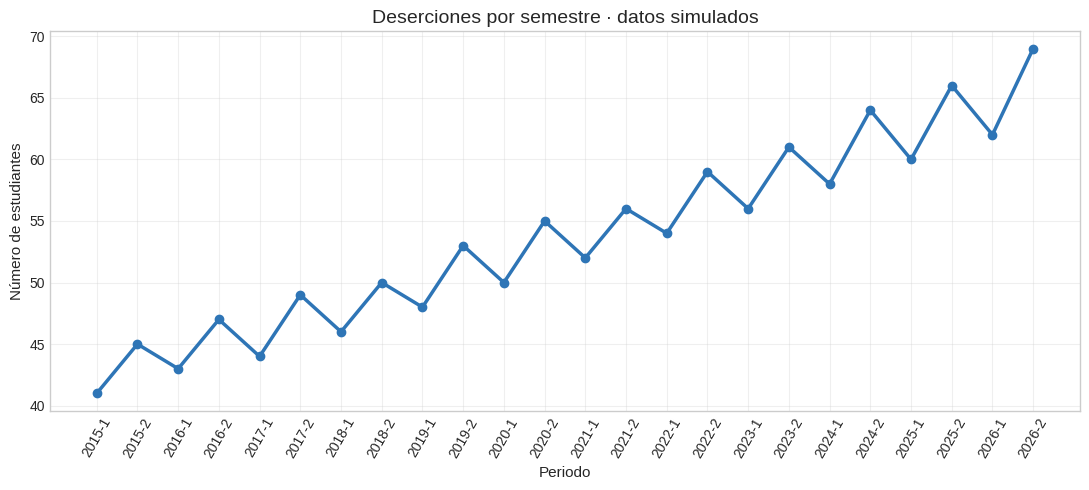

In [ ]:
fig, ax = plt.subplots()
ax.plot(df["Periodo"], df["Deserciones"], marker="o", linewidth=2.5, color="#2E75B6")
ax.set_title("Deserciones por semestre · datos simulados")
ax.set_xlabel("Periodo")
ax.set_ylabel("Número de estudiantes")
ax.tick_params(axis="x", rotation=60)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Cómo interpretar el resultado

Para leer la gráfica, recorra cuatro preguntas:

1. **Nivel:** ¿alrededor de qué altura se mueve la serie?
2. **Tendencia:** ¿el movimiento general es ascendente, descendente o estable?
3. **Estacionalidad:** ¿alguna forma se repite en periodos conocidos?
4. **Ruido:** ¿qué variaciones pequeñas no forman un patrón estable?

No concluya una tendencia por dos puntos aislados. Busque un comportamiento que persista durante varios periodos.


### Respuesta del estudiante

Describa con sus palabras el nivel, la tendencia, la posible estacionalidad y el ruido que observa. No utilice todavía métricas.

> **Escriba aquí su respuesta:**  
> La serie tiene un nivel que se ubica entre los 40 y 70 estudiantes y se mueve de forma consistente hacia arriba a lo largo del periodo observado. En general su tendencia es ascendente, aunque existen picos y bajadas se nota que se dan de forma regular. Se observa una posible estacionalidad, porque en el segundo semestre de cada año hay más deserciones que el primero. El ruido corresponde a las pequeñas variaciones que se presentan alrededor de ese patrón y de la tendencia ascendente.


## 5. Cuantificar nivel, tendencia y estacionalidad

La inspección visual es indispensable, pero podemos apoyarla con resúmenes sencillos. Calcularemos:

- Media y mediana como referencias globales de nivel.
- Pendiente lineal como resumen de la dirección general.
- Media por semestre para verificar la alternancia.
- Media móvil de cuatro periodos para suavizar fluctuaciones cortas.


Media global: 53.67
Mediana global: 53.50
Pendiente lineal aproximada por semestre: 1.04

Media por tipo de semestre:
Semestre
1    51.166667
2    56.166667

Diferencia promedio S2 - S1: 5.00


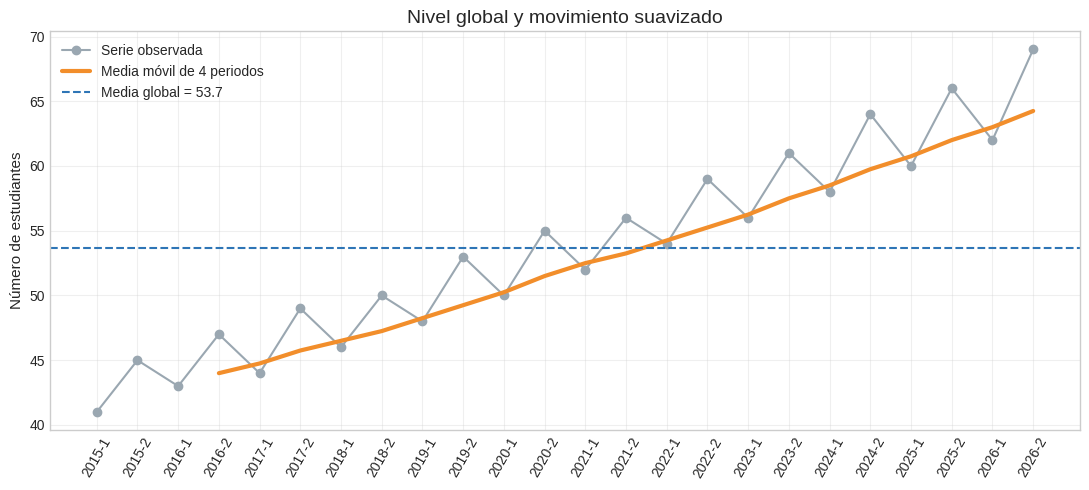

In [ ]:
media_global = df["Deserciones"].mean()
mediana_global = df["Deserciones"].median()
pendiente, intercepto = np.polyfit(df["t"], df["Deserciones"], 1)
media_por_semestre = df.groupby("Semestre")["Deserciones"].mean()
df["Media_movil_4"] = df["Deserciones"].rolling(4).mean()

print(f"Media global: {media_global:.2f}")
print(f"Mediana global: {mediana_global:.2f}")
print(f"Pendiente lineal aproximada por semestre: {pendiente:.2f}")
print("\nMedia por tipo de semestre:")
print(media_por_semestre.to_string())
print(f"\nDiferencia promedio S2 - S1: {media_por_semestre.loc[2] - media_por_semestre.loc[1]:.2f}")

fig, ax = plt.subplots()
ax.plot(df["Periodo"], df["Deserciones"], marker="o", color="#9AA7B1", label="Serie observada")
ax.plot(df["Periodo"], df["Media_movil_4"], linewidth=3, color="#F28E2B", label="Media móvil de 4 periodos")
ax.axhline(media_global, linestyle="--", color="#2E75B6", label=f"Media global = {media_global:.1f}")
ax.set_title("Nivel global y movimiento suavizado")
ax.set_ylabel("Número de estudiantes")
ax.tick_params(axis="x", rotation=60)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Cómo interpretar el resultado

- La media global resume toda la historia con un número; no representa necesariamente el nivel actual.
- Una pendiente positiva indica dirección ascendente, pero no garantiza que todos los semestres aumenten.
- Si la media del semestre 2 supera de forma consistente a la del semestre 1, existe evidencia descriptiva de una estructura estacional.
- La media móvil no pronostica por sí sola: ayuda a ver el movimiento persistente sin perseguir cada fluctuación.


### Respuesta del estudiante

Explique por qué la media global puede ser engañosa para decidir sobre el próximo semestre y qué evidencia numérica apoya la presencia de tendencia y estacionalidad.

> **Escriba aquí su respuesta:**  
> La media global de 53.67 es engañosa para decidir sobre el próximo semestre porque puede estar muy cerca o muy lejos de la tendencia en el futuro, ya que resume todos los datos históricos pero no considera una tendencia creciente, como es el caso. La tendencia ascendente se ratifica con la pendiente de 1.04 estudiantes por semestre. La estacionalidad se observa porque el promedio del semestre 2 es de 56.17 comparado con el de 51.17 cada semestre 1, la diferencia es de casi 5 estudiantes.


## 6. Definir origen, horizonte y conjunto de prueba

Para evaluar honestamente, simularemos que estamos al cierre de **2024-2**. Todo lo posterior se reservará como futuro desconocido.

- **Entrenamiento/historia disponible:** 2015-1 a 2024-2.
- **Prueba:** 2025-1 a 2026-2.
- **Horizonte:** un semestre en cada origen de evaluación.

Esta separación no es aleatoria: respeta la dirección del tiempo.


Historia disponible:
Periodo  Deserciones
 2022-2           59
 2023-1           56
 2023-2           61
 2024-1           58
 2024-2           64

Futuro reservado para evaluar:
Periodo  Deserciones
 2025-1           60
 2025-2           66
 2026-1           62
 2026-2           69


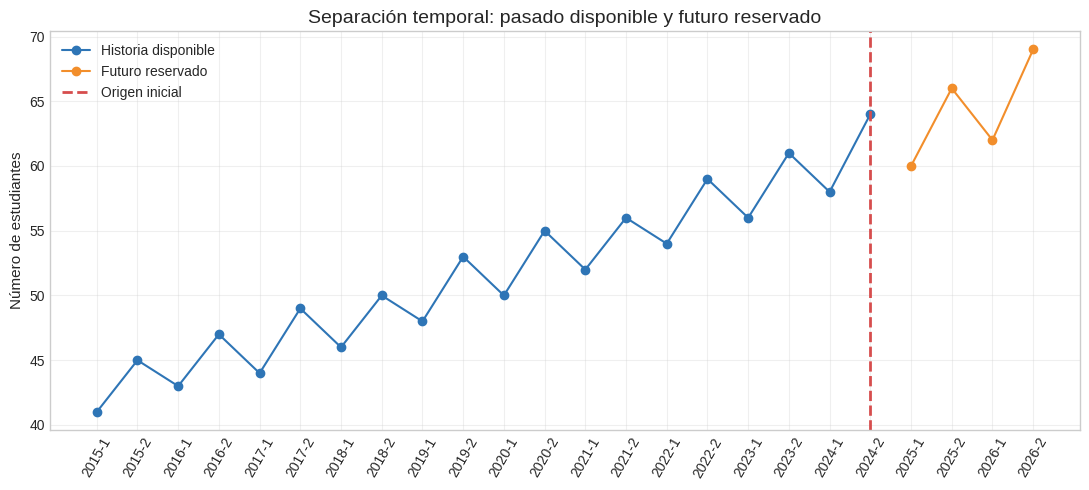

In [ ]:
indice_origen = df.index[df["Periodo"] == "2024-2"][0]
train = df.loc[:indice_origen].copy()
test = df.loc[indice_origen + 1:].copy()

print("Historia disponible:")
print(train[["Periodo", "Deserciones"]].tail(5).to_string(index=False))
print("\nFuturo reservado para evaluar:")
print(test[["Periodo", "Deserciones"]].to_string(index=False))

fig, ax = plt.subplots()
ax.plot(train["Periodo"], train["Deserciones"], marker="o", color="#2E75B6", label="Historia disponible")
ax.plot(test["Periodo"], test["Deserciones"], marker="o", color="#F28E2B", label="Futuro reservado")
ax.axvline("2024-2", color="#D64D4D", linestyle="--", linewidth=2, label="Origen inicial")
ax.set_title("Separación temporal: pasado disponible y futuro reservado")
ax.set_ylabel("Número de estudiantes")
ax.tick_params(axis="x", rotation=60)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Cómo interpretar el resultado

La línea vertical representa el origen inicial. Los valores naranjas existen en el dataset para comprobar el ejercicio, pero se tratan como desconocidos al construir cada pronóstico. Si se utilizaran para ajustar el método antes de predecirlos, ocurriría **fuga de información**.


### Respuesta del estudiante

Explique por qué una partición aleatoria sería inadecuada y qué información puede utilizarse para pronosticar 2025-1.

> **Escriba aquí su respuesta:**  
> Una partición aleatoria es inadecuada porque en una serie temporal debemos respetar el orden de los datos; siempre utilizamos la información que tenemos en un momento determinado para realizar el pronóstico de un periodo en el futuro. Para pronosticar 2025-1 podemos utilizar todos los datos desde el 2025-1 hasta el 2024-2. Los datos posteriores se deben tratar como si fueran desconocidos, para evitar la fuga de información.


## 7. Baseline 1: pronóstico naïve

El baseline naïve supone que el siguiente valor será igual al último observado:
$$
\hat{y}_{t}=y_{t-1}
$$

No pretende ser sofisticado. Su función es establecer un mínimo razonable que cualquier modelo más complejo debería superar.


In [ ]:
df["Pronostico_naive"] = df["Deserciones"].shift(1)

tabla_naive = df.loc[test.index, ["Periodo", "Deserciones", "Pronostico_naive"]].copy()
tabla_naive.columns = ["Periodo", "Real", "Naive"]
print(tabla_naive.to_string(index=False))


Periodo  Real  Naive
 2025-1    60   64.0
 2025-2    66   60.0
 2026-1    62   66.0
 2026-2    69   62.0


### Cómo interpretar el resultado

Para 2025-1, el método utiliza el valor de 2024-2. Después, en una evaluación de un paso, avanza el origen y utiliza el último valor real que ya habría quedado disponible. Por eso esta tabla representa una secuencia de pronósticos de horizonte 1, no un único pronóstico de cuatro semestres emitido desde 2024-2.


### Respuesta del estudiante

Identifique el pronóstico naïve de 2025-1 y explique con una oración cómo se obtuvo.

> **Escriba aquí su respuesta:**  
> El pronóstico naïve para 2025-1 es de 64 estudiantes porque simplemente toma el resultado del semestre inmediato anterior (2024-2), es una literalmente una copia.


## 8. Baseline 2: pronóstico estacional

Como la gráfica mostró una alternancia entre los semestres 1 y 2, utilizaremos el mismo semestre del año anterior:
$$
\hat{y}_{t}=y_{t-2}
$$


El rezago 2 tiene sentido porque la frecuencia es semestral: dos observaciones equivalen a un año.


Periodo  Real  Naive  Estacional
 2025-1    60   64.0        58.0
 2025-2    66   60.0        64.0
 2026-1    62   66.0        60.0
 2026-2    69   62.0        66.0


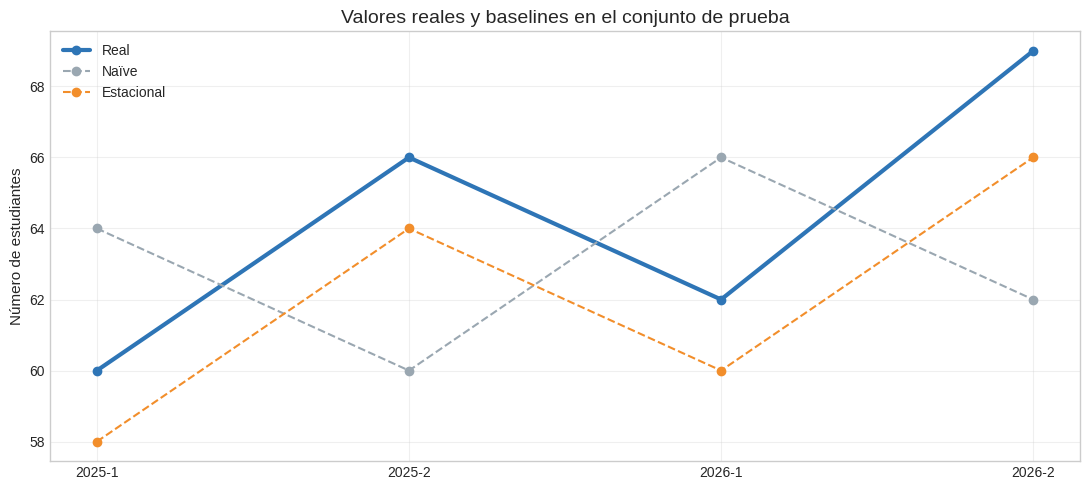

In [ ]:
df["Pronostico_estacional"] = df["Deserciones"].shift(2)

tabla_baselines = df.loc[test.index, [
    "Periodo", "Deserciones", "Pronostico_naive", "Pronostico_estacional"
]].copy()
tabla_baselines.columns = ["Periodo", "Real", "Naive", "Estacional"]
print(tabla_baselines.to_string(index=False))

fig, ax = plt.subplots()
ax.plot(tabla_baselines["Periodo"], tabla_baselines["Real"], marker="o", linewidth=3, label="Real", color="#2E75B6")
ax.plot(tabla_baselines["Periodo"], tabla_baselines["Naive"], marker="o", linestyle="--", label="Naïve", color="#9AA7B1")
ax.plot(tabla_baselines["Periodo"], tabla_baselines["Estacional"], marker="o", linestyle="--", label="Estacional", color="#F28E2B")
ax.set_title("Valores reales y baselines en el conjunto de prueba")
ax.set_ylabel("Número de estudiantes")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Cómo interpretar el resultado

Compare la forma, no solo la distancia. El naïve copia el semestre inmediatamente anterior y por ello puede quedar alto al pasar de un semestre 2 a un semestre 1. El estacional compara periodos equivalentes del calendario y conserva la alternancia observada.


### Respuesta del estudiante

¿Cuál baseline parece seguir mejor la forma de la serie? Justifique con dos periodos de la tabla.

> **Escriba aquí su respuesta:**  
> El pronóstico estacional se parece más a la forma de la serie, debido a que los periodos aumentan y decrecen de manera similar. Por ejemplo, en 2025-1 el valor real es 60 y el estacional 58, y cuando cambia a 2025-2 el valor real es 66 y el estacional pronostica 64. En contraste, el valor de naïve se mueve en sentido contrario.


## 9. Calcular el error periodo por periodo

Definimos el error como:

$$
e_t=y_t-\hat{y}_t
$$

- Si `error > 0`, el método **subestimó**: el valor real fue mayor.
- Si `error < 0`, el método **sobreestimó**: el pronóstico fue mayor.
- El error absoluto expresa cuánto se equivocó, sin considerar dirección.


In [ ]:
resultados = tabla_baselines.copy()
resultados["Error_naive"] = resultados["Real"] - resultados["Naive"]
resultados["Abs_naive"] = resultados["Error_naive"].abs()
resultados["Error_estacional"] = resultados["Real"] - resultados["Estacional"]
resultados["Abs_estacional"] = resultados["Error_estacional"].abs()

print(resultados.to_string(index=False))


Periodo  Real  Naive  Estacional  Error_naive  Abs_naive  Error_estacional  Abs_estacional
 2025-1    60   64.0        58.0         -4.0        4.0               2.0             2.0
 2025-2    66   60.0        64.0          6.0        6.0               2.0             2.0
 2026-1    62   66.0        60.0         -4.0        4.0               2.0             2.0
 2026-2    69   62.0        66.0          7.0        7.0               3.0             3.0


### Cómo interpretar el resultado

La tabla permite distinguir dos preguntas:

1. **Dirección:** ¿el método subestima o sobreestima?
2. **Magnitud:** ¿por cuántos estudiantes se equivoca?

Una métrica agregada resume la magnitud, pero puede ocultar la dirección. Por eso conviene conservar la tabla de errores antes de calcular promedios.


### Respuesta del estudiante

Indique en qué periodos el naïve subestimó y en cuáles sobreestimó. ¿Qué patrón observa en el error estacional?

> **Escriba aquí su respuesta:**  
> El pronóstico naïve sobreestima los periodos 1 y subestima los periodos 2. El pronóstico estacional siempre subestima, pero sus errores son pequeños y estables, de 2 o 3 estudiantes.


## 10. Resumir con MAE, RMSE y MAPE

Calcularemos tres métricas:

- **MAE:** error absoluto promedio, en estudiantes.
- **RMSE:** da mayor peso a errores grandes y vuelve a la unidad original.
- **MAPE:** error porcentual promedio; facilita comunicar proporciones, pero es inestable cerca de cero.

Ninguna métrica es universalmente mejor: debe elegirse según la escala y el costo de equivocarse.


    Método  MAE  RMSE  MAPE_%
     Naive 5.25  5.41    8.09
Estacional 2.25  2.29    3.48


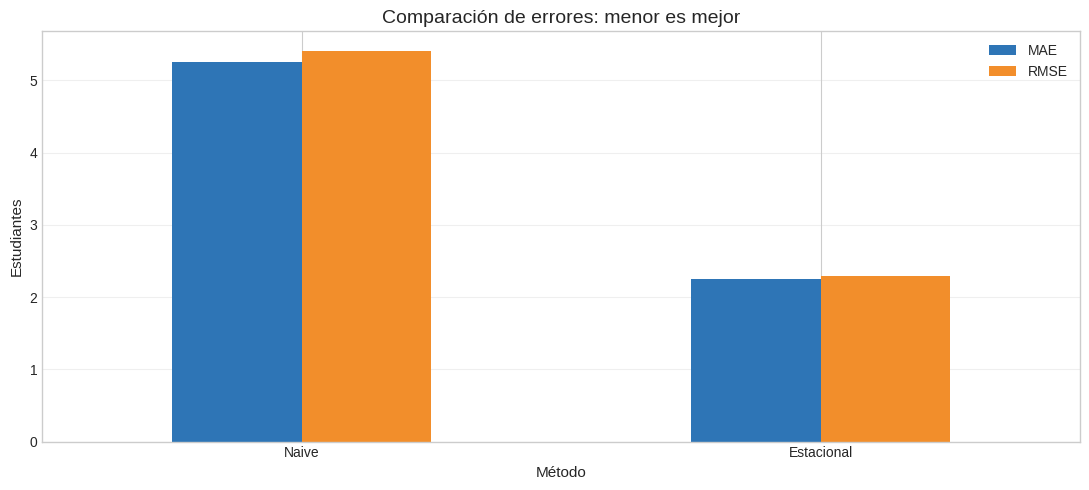

In [ ]:
def metricas(real, pronostico):
    real = np.asarray(real, dtype=float)
    pronostico = np.asarray(pronostico, dtype=float)
    error = real - pronostico
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / real)) * 100
    return mae, rmse, mape

filas_metricas = []
for nombre in ["Naive", "Estacional"]:
    mae, rmse, mape = metricas(resultados["Real"], resultados[nombre])
    filas_metricas.append({"Método": nombre, "MAE": mae, "RMSE": rmse, "MAPE_%": mape})

comparacion = pd.DataFrame(filas_metricas)
print(comparacion.round(2).to_string(index=False))

comparacion.set_index("Método")[["MAE", "RMSE"]].plot(
    kind="bar", color=["#2E75B6", "#F28E2B"], rot=0
)
plt.title("Comparación de errores: menor es mejor")
plt.ylabel("Estudiantes")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Cómo interpretar el resultado

- Un MAE de 2.25 significa que el método se equivoca, en promedio, por 2.25 estudiantes en estos orígenes.
- Si RMSE queda bastante por encima de MAE, existen errores grandes que reciben una penalización mayor.
- MAPE expresa el error relativo, pero en este caso no reemplaza la lectura en estudiantes, que es la unidad de la decisión.

La comparación solo es válida porque ambos métodos fueron evaluados sobre los mismos periodos.


### Respuesta del estudiante

Seleccione el baseline con mejor desempeño. Compare sus tres métricas y explique el significado práctico de su MAE.

> **Escriba aquí su respuesta:**  
> El baseline con mejor desempeño es el estacional, ya que presenta valores más bajos en todas sus métricas: MAE, 2.25 estudiantes, RMSE, 2.29 estudiantes y MAPE, 3.48%. En cambio, el pronóstico naïve con valores de 5.25, 5.41 y 8.09%, representa más del doble de error. El significado práctico del MAE indica que, en promedio, el pronóstico estacional se aleja del valor real por poco más de 2 estudiantes.


## 11. Incorporar el costo de subestimar

Las métricas anteriores penalizan por igual un error de `+4` y uno de `-4`. Sin embargo, el contexto indica que subestimar puede dejar estudiantes sin atención. Usaremos un costo ilustrativo:

- Cada unidad subestimada cuesta 2 puntos.
- Cada unidad sobreestimada cuesta 1 punto.

Este costo no es una verdad institucional; es un supuesto explícito para mostrar cómo la decisión cambia la evaluación.


In [ ]:
def costo_asimetrico(real, pronostico, peso_subestimar=2, peso_sobreestimar=1):
    error = np.asarray(real) - np.asarray(pronostico)
    costo = np.where(
        error > 0,
        peso_subestimar * np.abs(error),
        peso_sobreestimar * np.abs(error)
    )
    return costo

for metodo in ["Naive", "Estacional"]:
    resultados[f"Costo_{metodo}"] = costo_asimetrico(resultados["Real"], resultados[metodo])

print(resultados[["Periodo", "Real", "Naive", "Costo_Naive", "Estacional", "Costo_Estacional"]].to_string(index=False))
print("\nCosto promedio naïve:", resultados["Costo_Naive"].mean())
print("Costo promedio estacional:", resultados["Costo_Estacional"].mean())


Periodo  Real  Naive  Costo_Naive  Estacional  Costo_Estacional
 2025-1    60   64.0          4.0        58.0               4.0
 2025-2    66   60.0         12.0        64.0               4.0
 2026-1    62   66.0          4.0        60.0               4.0
 2026-2    69   62.0         14.0        66.0               6.0

Costo promedio naïve: 8.5
Costo promedio estacional: 4.5


### Cómo interpretar el resultado

El costo asimétrico conecta el desempeño estadístico con la consecuencia institucional. Un método puede tener un MAE razonable y aun así resultar inconveniente si se equivoca repetidamente en la dirección más costosa.

Aquí el baseline estacional sigue siendo preferible, aunque su subestimación sistemática merece atención. La conclusión no es ocultar el sesgo, sino comunicarlo para que la decisión incorpore un margen prudente.


### Respuesta del estudiante

¿Cambia la elección del baseline al duplicar el costo de subestimar? Explique y señale qué limitación permanece.

> **Escriba aquí su respuesta:**  
> No cambia la elección del baseline, ya que el pronóstico estacional sigue teniendo menor costo promedio, de 4.5 en contraste con el 8.5 del naïve. No obstante, debido a que el pronóstico estacional subestima siempre la deserción, debemos tomar en cuenta ese dato para planificar los recursos dejando un margen de seguridad.


## 12. Validación temporal rolling-origin

Una sola separación puede favorecer accidentalmente a un método. La validación rolling-origin repite el ensayo en varios momentos:

1. Se fija un origen histórico.
2. Se utiliza únicamente información anterior.
3. Se pronostica el siguiente periodo.
4. Se revela el valor real y se avanza el origen.

Así imitamos la forma en que el pronóstico se usaría en la realidad.


In [ ]:
evaluaciones = []

# Comenzamos en 2022-1 para reunir varios orígenes recientes.
inicio = df.index[df["Periodo"] == "2022-1"][0]

for i in range(inicio, len(df)):
    real = df.loc[i, "Deserciones"]
    pred_naive = df.loc[i - 1, "Deserciones"]
    pred_estacional = df.loc[i - 2, "Deserciones"]
    evaluaciones.append({
        "Origen": df.loc[i - 1, "Periodo"],
        "Periodo_pronosticado": df.loc[i, "Periodo"],
        "Real": real,
        "Naive": pred_naive,
        "Estacional": pred_estacional,
        "Abs_naive": abs(real - pred_naive),
        "Abs_estacional": abs(real - pred_estacional)
    })

rolling = pd.DataFrame(evaluaciones)
print(rolling.to_string(index=False))
print("\nMAE rolling-origin naïve:", round(rolling["Abs_naive"].mean(), 2))
print("MAE rolling-origin estacional:", round(rolling["Abs_estacional"].mean(), 2))


Origen Periodo_pronosticado  Real  Naive  Estacional  Abs_naive  Abs_estacional
2021-2               2022-1    54     56          52          2               2
2022-1               2022-2    59     54          56          5               3
2022-2               2023-1    56     59          54          3               2
2023-1               2023-2    61     56          59          5               2
2023-2               2024-1    58     61          56          3               2
2024-1               2024-2    64     58          61          6               3
2024-2               2025-1    60     64          58          4               2
2025-1               2025-2    66     60          64          6               2
2025-2               2026-1    62     66          60          4               2
2026-1               2026-2    69     62          66          7               3

MAE rolling-origin naïve: 4.5
MAE rolling-origin estacional: 2.3


### Cómo interpretar el resultado

Cada fila es un pequeño experimento fuera de muestra. El origen avanza y el futuro nunca entra antes de tiempo. Si el mismo método supera al otro en varios orígenes, la conclusión es más sólida que con una sola división.

La validación no demuestra que el método siempre funcionará: estima cómo habría funcionado bajo condiciones históricas semejantes.


### Respuesta del estudiante

Compare los MAE rolling-origin y explique por qué esta evidencia es más convincente que una sola separación.

> **Escriba aquí su respuesta:**  
> Esta evidencia es más convincente que una sola separación porque nos muestra un transcurso más largo en el cual podemos cuantificar la efectividad de nuestras predicciones. Cuando comparamos el MAE rolling-origin del naïve que es 4.5 y el estacional 2.3, observamos que el estacional sigue manteniendo el menor error promedio.


## 13. Emitir un pronóstico de referencia y tomar una decisión

Ya evaluamos los métodos. Ahora estamos al cierre de **2026-2** y queremos anticipar **2027-1**.

El baseline estacional utiliza el valor de 2026-1 porque corresponde al mismo semestre del año anterior. También mostraremos el naïve para conservar la comparación.


In [ ]:
pronostico_2027_1_naive = df.iloc[-1]["Deserciones"]
pronostico_2027_1_estacional = df.iloc[-2]["Deserciones"]

print(f"Pronóstico naïve para 2027-1: {pronostico_2027_1_naive}")
print(f"Pronóstico estacional para 2027-1: {pronostico_2027_1_estacional}")

# Margen ilustrativo basado en el MAE del baseline estacional en el conjunto de prueba.
mae_estacional = comparacion.loc[comparacion["Método"] == "Estacional", "MAE"].iloc[0]
capacidad_sugerida = int(np.ceil(pronostico_2027_1_estacional + mae_estacional))
print(f"Capacidad preventiva ilustrativa: {capacidad_sugerida} estudiantes")


Pronóstico naïve para 2027-1: 69
Pronóstico estacional para 2027-1: 62
Capacidad preventiva ilustrativa: 65 estudiantes


### Cómo interpretar el resultado

El pronóstico y la decisión no son lo mismo:

- **Pronóstico de referencia:** el baseline estacional estima 62 deserciones.
- **Decisión ilustrativa:** por el costo de subestimar, la coordinación podría reservar capacidad para 65 estudiantes.

El margen no altera retroactivamente el pronóstico ni constituye un intervalo estadístico formal. Es una regla de decisión transparente basada en el error histórico y en una preferencia institucional. En un proyecto real, el costo y el margen deben acordarse con responsables del proceso.


### Respuesta del estudiante

Redacte una recomendación de cuatro a seis oraciones que separe claramente pronóstico, error esperado, decisión y limitación.

> **Escriba aquí su respuesta:**  
> El método estacional nos indica un pronóstico para 2017-1 de 62 deserciones. Debido a que el MAE histórico es de 2.25 estudiantes, se espera que el valor real tenga esta diferencia aproximada. En conclusión, sugerimos que se abra espacio para 65 estudiantes ya que este margen nos da la oportunidad de responder a una demanda mayor y evitamos la falta de recursos. Como limitación, se debe recordar que este modelo tiende a subestimar sistemáticamente por lo que el pronóstico debe usarse como una guía y no como una verdad absoluta.


## 14. Síntesis final

Complete esta estructura sin copiar literalmente las explicaciones anteriores:

> La decisión analizada fue __________. La serie tuvo frecuencia __________ y mostró principalmente __________. Comparamos los baselines __________ y __________. El mejor fue __________ porque obtuvo __________. El resultado significa que __________. Para apoyar la decisión recomendamos __________, aunque debe considerarse la limitación de __________.


### Respuesta del estudiante

Redacte una conclusión integrada de 120 a 180 palabras.

> **Escriba aquí su respuesta:**  
> La decisión analizada fue la planificación anticipada de recursos y espacios académicos para el periodo 2027-1. La serie tuvo frecuencia semestral y mostró principalmente una tendencia ascendente con un comportamiento repetitivo de mayores deserciones en el semestre 2. Comparamos los baselines naïve y estacional usando las métricas MAE, RMSE, MAPE y validación rolling-origin. El mejor fue el pronóstico estacional porque obtuvo MAE de 2.25 estudiantes, RMSE de 2.29 y MAPE de 3.48%. El resultado significa que el pronóstico estacional tiene un margen de error absoluto promedio de 2.25 estudiantes, con una tendencia sistemática a subestimar. Para apoyar la decisión recomendamos utilizar el pronóstico estacional que indica 62 deserciones, aunque debe considerarse la limitación de la subestimación constante, por lo que se sugiere que se programe todo para 65 deserciones. Este margen está basado en el comportamiento histórico, así que no garantiza el valor futuro real.


## Entrega

1. Cambie el nombre del archivo a: `Matricula_Apellido_Laboratorio1.ipynb`.
2. Verifique que todas las celdas de código tengan salida.
3. Complete todas las secciones **Respuesta del estudiante**.
4. Descargue el cuaderno mediante **Archivo → Descargar → Descargar .ipynb**.
5. Entregue el archivo en la asignación de Teams correspondiente.

### Rúbrica · 100 puntos

| Criterio | Puntos |
|---|---:|
| Ejecución completa y evidencia de resultados | 15 |
| Formulación temporal: decisión, variable, frecuencia, origen y horizonte | 20 |
| Lectura de nivel, tendencia, estacionalidad y ruido | 20 |
| Interpretación de baselines, errores y métricas | 25 |
| Validación temporal y recomendación final | 15 |
| Claridad, redacción y uso correcto de unidades | 5 |

### Lista de comprobación

- [ ] No confundí pronóstico con meta o decisión.
- [ ] Respeté la información disponible en cada origen.
- [ ] Interpreté MAE en estudiantes, no solo como un número.
- [ ] Expliqué por qué el baseline estacional fue mejor.
- [ ] Mencioné la subestimación sistemática como limitación.
- [ ] Separé el pronóstico de 62 de la capacidad sugerida de 65.

---

### Referencias

- Hyndman, R. J. y Athanasopoulos, G. *Forecasting: Principles and Practice*, 3.ª ed.: https://otexts.com/fpp3/
- Evaluación temporal de series: https://otexts.com/fpp3/tscv.html
- Documentación de pandas: https://pandas.pydata.org/docs/
- Documentación de Matplotlib: https://matplotlib.org/stable/
